<a href="https://colab.research.google.com/github/pankaj201004/RL-ALL-EXPERIMENT/blob/main/rl_exp_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Multi-Armed Bandit

The agent must choose between k different slot machines (arms).

Each arm gives a random reward based on a probability distribution.

The goal is to maximize the total reward over time.

The challenge: Balancing exploration (trying new arms) vs. exploitation (sticking to the best arm).

Exploration Strategies

Epsilon-Greedy: With probability e, the agent explores a random action, otherwise, it exploits the best known action.

Upper Confidence Bound (UCB1): Selects actions based on both the estimated reward and uncertainty.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
print("pankaj yadav 221A035")

pankaj yadav 221A035


Step 1: To create multiArmedBandit Class


In [ ]:
class MultiArmedBandit:
  def __init__(self, k=10):
    self.k = k
    self.q_true = np.random.normal(0,1,k) # true rewards for each arm
    self.best_arm = np.argmax(self.q_true)
  def pull_arm(self, arm):
    return np.random.normal(self.q_true[arm],1)#rewards with some noise
print("pankaj yadav 221A035")

pankaj yadav 221A035


Step 2: To create agent Class


In [ ]:
class Agent:
  def __init__(self, bandit, stratergy="epsilon_greedy", epsilon=0.1, c=2):
    self.bandit = bandit
    self.stratergy = stratergy
    self.epsilon = epsilon
    self.c = c
    self.k=bandit.k
    self.Q = np.zeros(self.k) # ESTIMATED REWARDS
    self.N = np.zeros(self.k) # NUMBER OF TIMES EACH ARM WAS PULLED

  def select_arm(self,t):
    if self.stratergy == "epsilon_greedy":
      if np.random.rand() < self.epsilon:#random action
        return np.random.randint(self.k)#exploit best knoen action
      return np.argmax(self.Q)
    elif self.stratergy == "ucb1":
      if 0 in self.N: # Ensure all arms are tried at least once
       return np.argmin(self.N)
      return np.argmax(self.Q +self.c * np.sqrt(np.log(t + 1) / self.N))
    elif self.stratergy == "thompson_sampling": # Fixed typo 'strategy' to 'stratergy'
     samples = np.random.normal (self.Q, 1 / (self.N + 1)) # Sample from belief
     return np.argmax(samples)

  def update(self, arm, reward): # Corrected indentation to be a method of Agent
    self.N[arm] += 1
    self.Q[arm] +=(reward - self.Q[arm]) / self.N[arm]#incremental mean update
print("pankaj yadav 221A035")

pankaj yadav 221A035


Implements Epsilon-Greedy, and UCB1 exploration agents

Updates Q-values using the incremental mean method.

Step 3: To create function to estimate average reward for each strategy.

In [ ]:
def run_strategy(k=10, steps=1000, runs=200, strategies=["epsilon_greedy", "ucb1"]):
  avg_rewards = {strategy: np.zeros(steps) for strategy in strategies}
  for strategy in strategies:
    for run in range(runs):
      bandit = MultiArmedBandit(k)
      agent = Agent(bandit, stratergy=strategy)
      rewards = np.zeros(steps)
      for t in range(steps):
        action = agent.select_arm(t)
        reward = bandit.pull_arm(action)
        agent.update(action, reward)
        rewards[t] = reward
      avg_rewards[strategy] += rewards / runs
  return avg_rewards
print("pankaj yadav 221A035")

pankaj yadav 221A035


Runs multiple trials of each strategy.

Averages the rewards over multiple runs for reliable results.

Step 4: To run the experiment to estimate average reward.

In [ ]:
# Run the experiment
print("pankaj yadav 221A035")
strategies = ["epsilon_greedy", "ucb1"]
results = run_strategy()

pankaj yadav 221A035


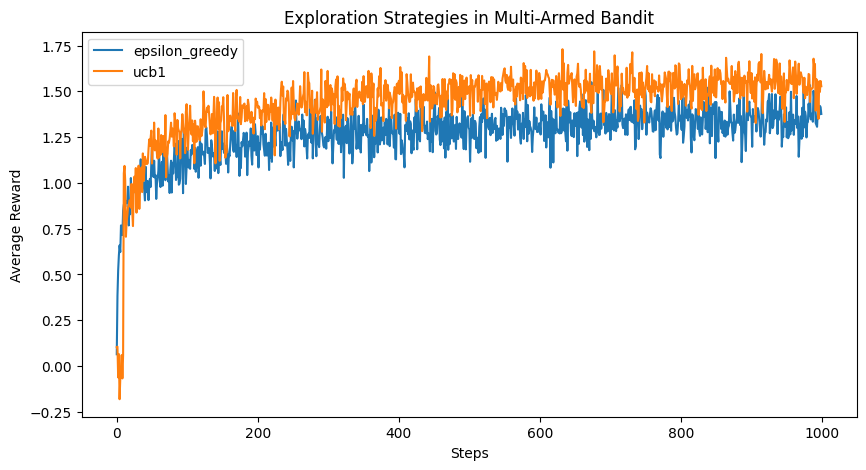

In [ ]:
# Plot the results
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
for strategy, rewards in results.items():
    plt.plot(rewards, label=strategy)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.title("Exploration Strategies in Multi-Armed Bandit")
plt.show()

Observations

Initial Phase (First 100 Steps)

Both strategies start with low rewards and improve over time.

UCB1 shows a faster initial learning rate, meaning it finds better arms more quickly.

Middle Phase (100-500 Steps)

UCB1 consistently outperforms Epsilon-Greedy with slightly higher rewards.

Epsilon-Greedy fluctuates more, as it keeps exploring randomly with probability є.

Final Phase (500-1000 Steps)

UCB1 stabilizes at a slightly higher average reward.

Epsilon-Greedy keeps fluctuating due to its continued exploration.

UCB1's confidence-based exploration leads to better long-term exploitation.